In [30]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython import display
import pylab as pl

from visualization_utils import display_matrix, subplot_1D_signals
from bss_utils import generate_uncorrelated_uniform_sources, addWGN

# Generate Sources and Mix Them (2 by 2 case)

In [244]:
# np.random.seed(0)
N = 100000
NumberofSources = 2
NumberofMixtures = 2

S = generate_uncorrelated_uniform_sources(NumberofSources, N)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# Generate Mxr random mixing from i.i.d N(0,1)
# A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
A = ortho_group.rvs(dim=2) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)

SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))

The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.9955187353361


# Hyperparameters

In [263]:
L = 2*np.eye(2)
W = np.eye(2)

# L = np.random.randn(2, 2)
# W = np.random.randn(2, 2)

muW = 30 * 1e-4
synaptic_lr_decay_divider=5000
lambdaL = 1 - 0.0001

neural_lr_start = 0.3
neural_lr_stop = 1e-8
neural_dynamics_iterations = 100
debug_iteration_point = 10000

In [264]:
samples = N
idx = np.random.permutation(samples)  # random permutation
for i_sample in tqdm(range(samples)):
    x_current = X[:, idx[i_sample]]
    y = np.zeros(2)

    y = run_neural_dynamics(x_current, y, W, L, neural_lr_start, neural_lr_stop)
    e = y - W @ x_current
    muW_ = np.max(
                [
                    muW
                    / (1 + np.log(2 + (i_sample // synaptic_lr_decay_divider))),
                    1e-3,
                ]
            )

    W = W + muW_ * np.outer(e, x_current)
    L = lambdaL * L + (1 - lambdaL) * np.outer(y, y)
    if ((i_sample % debug_iteration_point) == 0) | (
                        i_sample == samples - 1
                    ):
        Wf = compute_overall_mapping(W, L)
        Y_ = Wf @ X
        Y_ = signed_and_permutation_corrected_sources(S, Y_)
        coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1)
        Y_ = coef_ * Y_
        SINR = 10 * np.log10(CalculateSINRjit(Y_, S, False)[0])
        print("SINR: {}".format(SINR))
        print("Component SNR Values : {}\n".format(snr_jit(S, Y_)))
    if i_sample > 10000:
        break

  0%|▎                                                                     | 440/100000 [00:00<00:40, 2465.53it/s]

SINR: 7.810749459148417
Component SNR Values : [8.45905906 8.49306   ]



 10%|██████▊                                                             | 10001/100000 [00:02<00:19, 4568.16it/s]

SINR: 22.594095214572995
Component SNR Values : [22.00498849 23.33025151]



In [265]:
y

array([-1.,  1.])

In [266]:
W, L

(array([[ 1.40359671,  0.44952168],
        [-0.46818187,  1.38442466]]),
 array([[ 1.28108799, -0.00410056],
        [-0.00410056,  1.28115644]]))

In [267]:
Wf = compute_overall_mapping(W, L)
Y = Wf @ X
Y_ = signed_and_permutation_corrected_sources(S, Y)
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1)
Y_ = coef_ * Y_

print("Component SNR Values : {}\n".format(snr_jit(S, Y_)))

SINR = 10 * np.log10(CalculateSINRjit(Y_, S)[0])

print("Overall SINR : {}".format(SINR))

Component SNR Values : [21.96200084 23.37415732]

Overall SINR : 22.587809530069958


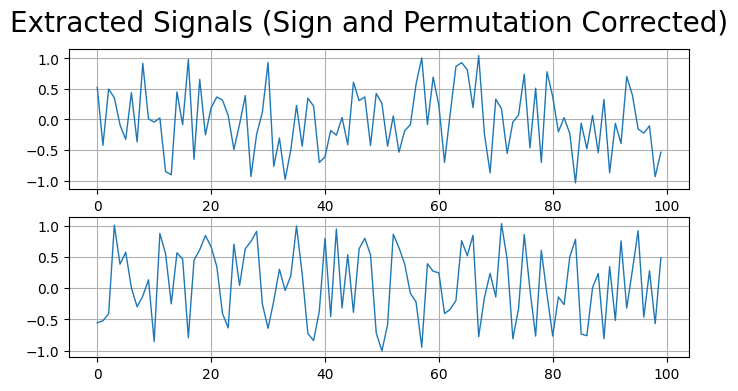

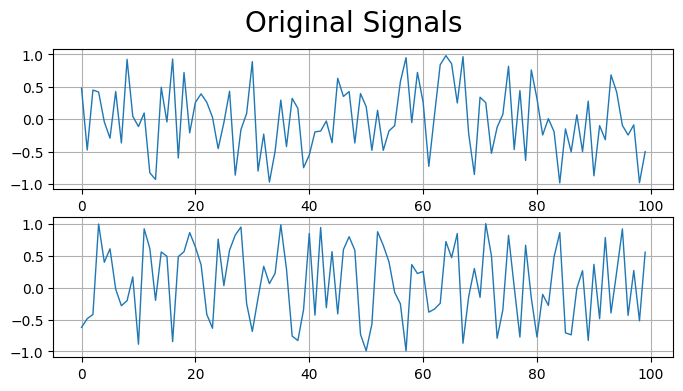

In [268]:
subplot_1D_signals(
    Y_[:, 0:100],
    title="Extracted Signals (Sign and Permutation Corrected)",
    figsize=(8, 4),
    colorcode=None,
)
subplot_1D_signals(
    S[:, 0:100], title="Original Signals", figsize=(8, 4), colorcode=None
)

In [120]:
@njit(parallel=True)
def snr_jit(S_original, S_noisy):
    N_hat = S_original - S_noisy
    N_P = (N_hat**2).sum(axis=1)
    S_P = (S_original**2).sum(axis=1)
    snr = 10 * np.log10(S_P / N_P)
    return snr
        
def outer_prod_broadcasting(A, B):
        """Broadcasting trick."""
        return A[..., None] * B[:, None]
    
def find_permutation_between_source_and_estimation( S, Y):
    """
    S    : Original source matrix
    Y    : Matrix of estimations of sources (after BSS or ICA algorithm)

    return the permutation of the source seperation algorithm
    """
    # perm = np.argmax(np.abs(self.outer_prod_broadcasting(Y,S).sum(axis = 0))/(np.linalg.norm(S,axis = 0)*np.linalg.norm(Y,axis=0)), axis = 0)
    perm = np.argmax(
        np.abs(outer_prod_broadcasting(Y.T, S.T).sum(axis=0))
        / (np.linalg.norm(S, axis=1) * np.linalg.norm(Y, axis=1)),
        axis=0,
    )
    return perm

def signed_and_permutation_corrected_sources( S, Y):
    """_summary_

    Args:
        S (_type_): _description_
        Y (_type_): _description_

    Returns:
        _type_: _description_
    """
    perm = find_permutation_between_source_and_estimation(S, Y)
    return (np.sign((Y[perm, :] * S).sum(axis=1))[:, np.newaxis]) * Y[perm, :]
    
def compute_overall_mapping(W, L):
    I = np.eye(*L.shape)
    W_ = np.linalg.solve(I - L, W)
    return W_

@njit
def CalculateSINRjit(Out, S, compute_permutation=True):
    def mean_numba(a):
        res = []
        for i in range(a.shape[0]):
            res.append(a[i, :].mean())

        return np.array(res)

    r = S.shape[0]
    Smean = mean_numba(S)
    Outmean = mean_numba(Out)
    if compute_permutation:
        G = np.dot(
            Out - np.reshape(Outmean, (r, 1)),
            np.linalg.pinv(S - np.reshape(Smean, (r, 1))),
        )
        # G = np.linalg.lstsq((S-np.reshape(Smean,(r,1))).T, (Out-np.reshape(Outmean,(r,1))).T)[0]
        indmax = np.abs(G).argmax(1).astype(np.int64)
    else:
        G = np.dot(
            Out - np.reshape(Outmean, (r, 1)),
            np.linalg.pinv(S - np.reshape(Smean, (r, 1))),
        )
        # G = np.linalg.lstsq((S-np.reshape(Smean,(r,1))).T, (Out-np.reshape(Outmean,(r,1))).T)[0]
        indmax = np.arange(0, r)

    GG = np.zeros((r, r))
    for kk in range(r):
        GG[kk, indmax[kk]] = np.dot(
            Out[kk, :] - Outmean[kk], S[indmax[kk], :].T - Smean[indmax[kk]]
        ) / np.dot(
            S[indmax[kk], :] - Smean[indmax[kk]],
            S[indmax[kk], :].T - Smean[indmax[kk]],
        )  # (G[kk,indmax[kk]])

    ZZ = GG @ (S - np.reshape(Smean, (r, 1))) + np.reshape(Outmean, (r, 1))
    E = Out - ZZ
    MSE = np.linalg.norm(E) ** 2
    SigPow = np.linalg.norm(ZZ) ** 2
    SINR = SigPow / MSE
    return SINR, SigPow, MSE, G

In [47]:
@njit
def run_neural_dynamics(x, y,
                        W, L,
                        neural_lr_start,
                       neural_lr_stop,
                       neural_OUTPUT_COMP_TOL=1e-7,):
    yke = np.dot(W, x)
    for j in range(neural_dynamics_iterations):
        mu_y = max(neural_lr_start / (j + 1), neural_lr_stop)
        y_old = y.copy()
        error = y - yke
        lateral = np.dot(L, y)
        grady = error - lateral
        y = y - mu_y * grady
        y = np.clip(y, -1, 1)
        if np.linalg.norm(y - y_old) < neural_OUTPUT_COMP_TOL * np.linalg.norm(y):
            break
    return y

In [13]:
np.linalg.det(np.diag(np.diag(np.outer(z, z))))

np.float64(2.089157853852471)

In [15]:
np.linalg.det(np.outer(z, z))

np.float64(0.0)

In [16]:
z

array([-0.77726627, -1.40004728,  2.33575774,  3.4804338 , -0.1633849 ])